# HW3 Playground

Fill in TODOs as you work through the assignment.
Implement the required sections in `model.py`, and use this notebook to orchestrate and run your solution.

In [2]:
%load_ext autoreload
%autoreload 2

from hw3_loader import HW3DataLoader
from model import svm_classifier, svm_regressor
from model import evaluate_classifier, evaluate_regressor
from utils import (
    plot_classification_results,
    plot_regression_results,
    plot_residuals,
    explore_classification_data,
    apply_pca,
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


## Data Loading

Successfully loaded heart disease data with 1025 rows
(1025, 13)
features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
(1025,)
aging data: (37, 485516)
columns Index(['dataset', 'tissue_type', 'age', 'gender', 'cg00000029', 'cg00000108',
       'cg00000109', 'cg00000165', 'cg00000236', 'cg00000289'],
      dtype='object')
############ SUMMARY STATS ################
Heart Dataset:
                mean        std  median
age        54.434146   9.067864    56.0
sex         0.695610   0.460149     1.0
cp          0.942439   1.029138     1.0
trestbps  131.611707  17.508171   130.0
chol      246.000000  51.567337   240.0
fbs         0.149268   0.356353     0.0
restecg     0.529756   0.527620     1.0
thalach   149.114146  22.994499   152.0
exang       0.336585   0.472542     0.0
oldpeak     1.071512   1.174480     0.8
slope       1.385366   0.617454     1.0
ca          0.754146   1.030295     0.0
thal        2.323902   0.620

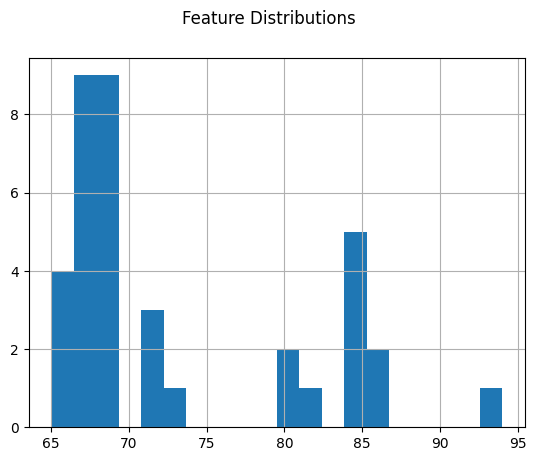

In [3]:
loader = HW3DataLoader()
X_clf, y_clf = loader.get_heart_disease_data('../data/heart.csv')
df_aging = loader.get_aging_data(pickle_path="../data/GSE139307.pkl")

# TODO: Inspect dataset shapes and missing values
heart_features = X_clf.columns.tolist()
print(X_clf.shape)
print('features:', heart_features)
print(y_clf.shape)

print('aging data:', df_aging.shape)
print('columns', df_aging.columns[:10])
sum_stats = {}

for feature in heart_features:
    sum_stats[feature] = {}
    feature_col = X_clf[feature]
    mean = np.mean(feature_col)
    # print(mean)
    std = np.std(feature_col)
    median = np.median(feature_col)
    sum_stats[feature]['mean'] = mean
    sum_stats[feature]['std'] = std
    sum_stats[feature]['median'] = median


# TODO: Print basic summary statistics for each dataset
print('############ SUMMARY STATS ################')
print("Heart Dataset:")
print(pd.DataFrame(sum_stats).T)
print('--------------------------------------')
print("Aging dataset")
age = df_aging['age']
print(pd.DataFrame({'mean': np.mean(age), 'std': np.std(age), 'median': np.median(age)}, index=['age']))
age.hist(bins=20)
plt.suptitle("Feature Distributions")
plt.show()





## Classification Task (Heart Disease)

Exploring classification dataset...


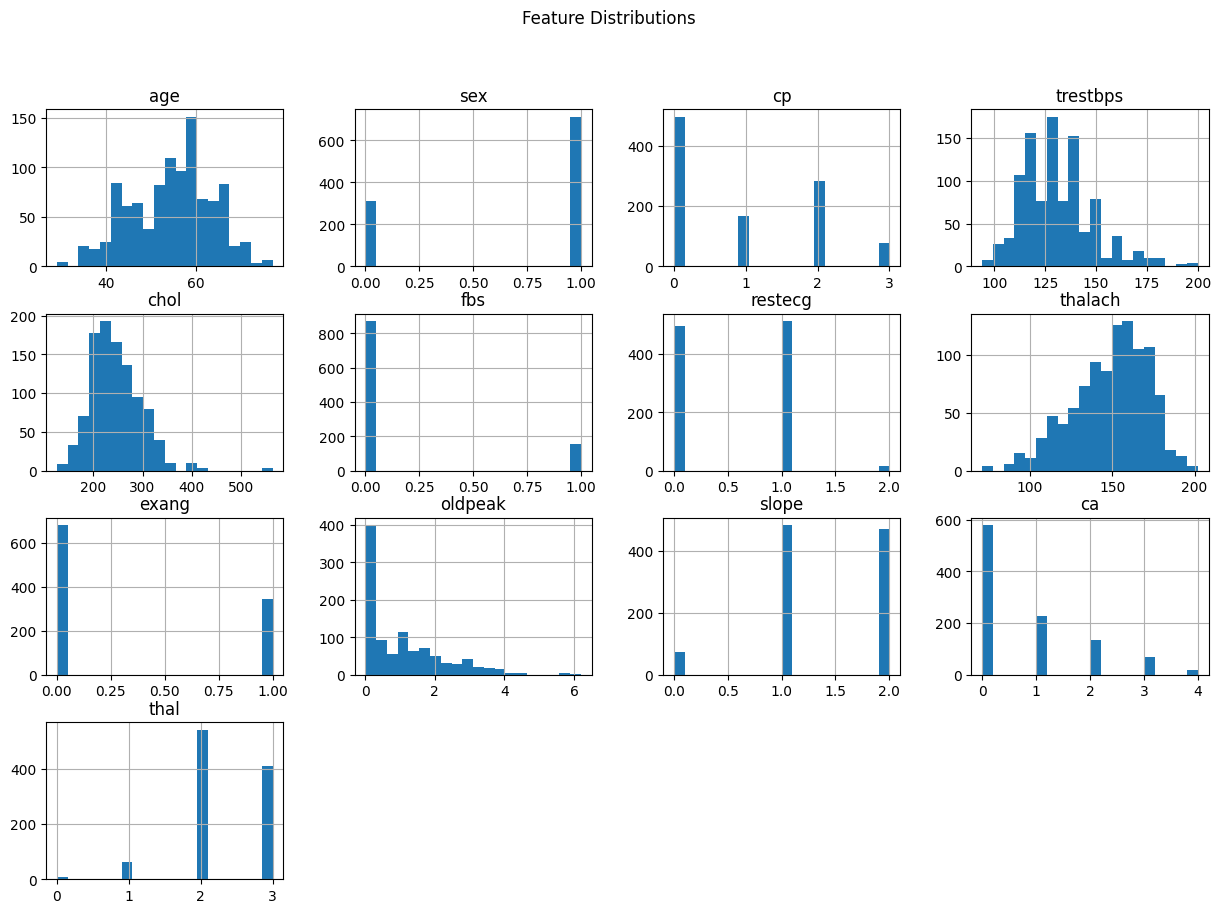

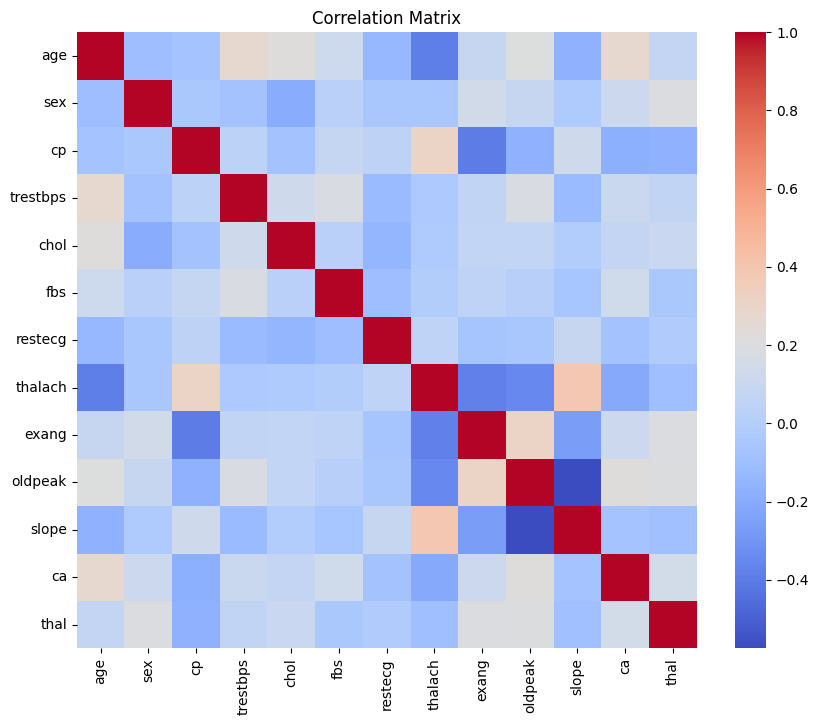

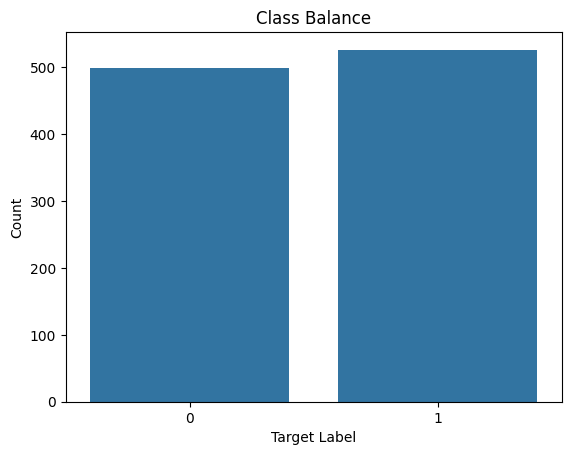

In [4]:
# TODO: Use explore_classification_data to show histograms, correlations, and class balance
# Use utils

explore_classification_data(X_clf, y_clf)

In [5]:
# TODO: Split X_clf and y_clf into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, random_state=42)


### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVM)

In [6]:
# TODO: Build a leakage-free pipeline for classification
# Example skeleton:
pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    # ("pca", PCA()),
    ("model", svm_classifier()),
])


### Kernel Experiments

In [7]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
kernels = ["linear", "poly", "rbf"]
kernel_summary = {kernel: {} for kernel in kernels}
# TODO: Tune hyperparameters (C, degree, gamma)


# TODO: Fit models and track metrics
for kernel in kernels:
    print(kernel)
    svc = svm_classifier(kernel=kernel)
    pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),   
    ("pca", PCA(n_components=6)),
    ("model", svc),
])
    params = {"model__C": [0.01,0.1, 1, 10, 100 ], 
              "pca__n_components": [4, 6, 8, 10, 13]}
    
    if kernel == 'poly':
        params["model__degree"] = [2, 3, 4]

    if kernel == "rbf":
        params["model__gamma"] = [0.001, 0.01, 0.1, 1]

    
    
    grid = GridSearchCV(pipeline, params, cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    accuracy, precision,recall, f1 = evaluate_classifier(best_model, X_test, y_test)
    kernel_summary[kernel] = {'accuracy': accuracy, 
                              'precision': precision, 
                              'recall': recall,
                              'f1': f1,
                              'best_params': grid.best_params_ 
                              }
pd.set_option("display.max_colwidth", None)
print(pd.DataFrame(kernel_summary))
# print(pd.DataFrame(kernel_summary['poly']))
# print(pd.DataFrame(kernel_summary['rbf']))
# TODO: Compare kernels and select best model


linear
poly
rbf
                                                linear  \
accuracy                                      0.789883   
precision                                     0.748252   
recall                                           0.856   
f1                                            0.798507   
best_params  {'model__C': 10, 'pca__n_components': 13}   

                                                                       poly  \
accuracy                                                           0.976654   
precision                                                               1.0   
recall                                                                0.952   
f1                                                                  0.97541   
best_params  {'model__C': 100, 'model__degree': 3, 'pca__n_components': 13}   

                                                                         rbf  
accuracy                                                            0.988327  
pr

### Classification Metrics and Visuals

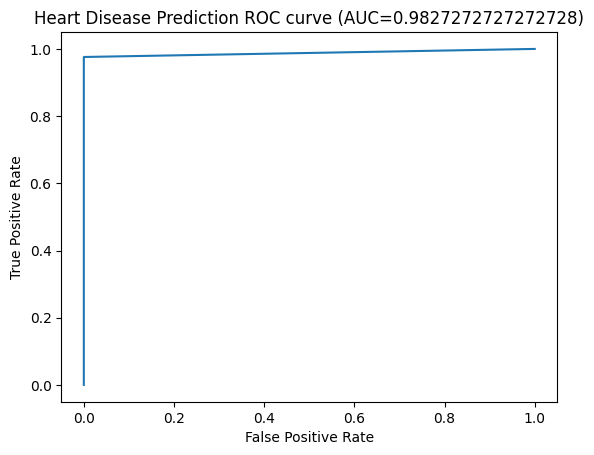

/Users/vanessaalexander/cs1851/homework-3-valexander21/.hw3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Heart Disease Prediction (Logistic Regression) Confusion Matrix')

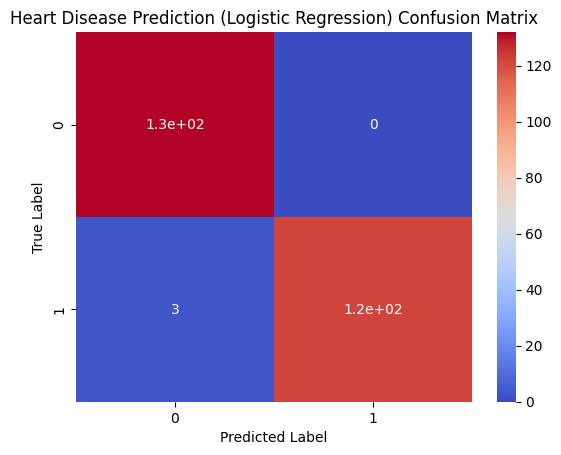

In [8]:
# TODO: Compute accuracy and F1
svc = svm_classifier('rbf', C=100, gamma=0.1)
pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),   
    ("pca", PCA(n_components=10)),
    ("model", svc),])
pipeline.fit(X_train, y_train)
accuracy, _, _, f1 = evaluate_classifier(pipeline, X_test, y_test)
# TODO: Compute ROC-AUC or PR-AUC
y_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred = pipeline.predict(X_test)
auc = roc_auc_score(y_test, y_proba)
# TODO: Plot confusion matrix and ROC/PR curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Heart Disease Prediction ROC curve (AUC={auc})")
plt.savefig("../outputs/heart/roc_curve.png")
plt.show()


plot_classification_results(X_test, y_test, pipeline, "../outputs/heart/class_results.png")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="coolwarm")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig('../outputs/heart/cm.png')
plt.title("Heart Disease Prediction (Logistic Regression) Confusion Matrix")


### Hyperparameter Sensitivity

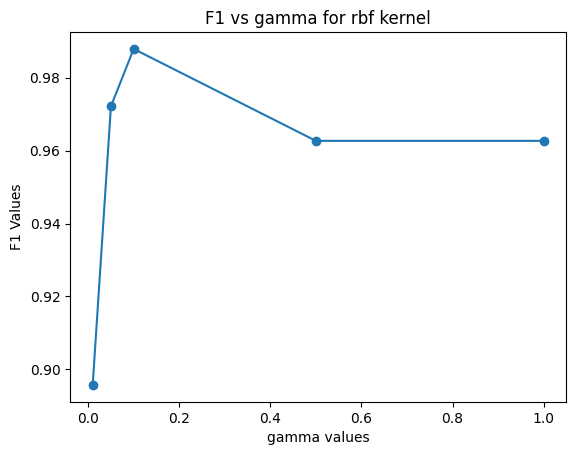

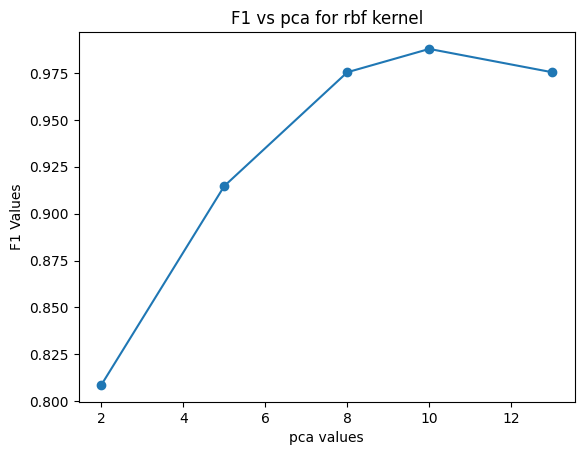

In [9]:
# TODO: Make 1-2 concise visuals of performance vs C/gamma/degree
# Example: line plot of F1 vs C for a fixed kernel
def perform_var(values, var, kernel: str = "rbf"):
    f1_scores = []
    for value in values: 
        if var == 'gamma':
            svc = svm_classifier(kernel, gamma=value, C=100)
            pipeline = Pipeline([
            ("imputer", SimpleImputer()),
            ("scaler", StandardScaler()),   
            ("pca", PCA(n_components=10)),
            ("model", svc),])
        elif var == 'C':
            svc = svm_classifier(kernel, C=value, gamma=0.1)
            pipeline = Pipeline([
            ("imputer", SimpleImputer()),
            ("scaler", StandardScaler()),   
            ("pca", PCA(n_components=10)),
            ("model", svc),])
        else: 
            svc = svm_classifier(kernel, C=100, gamma=0.1)
            pipeline = Pipeline([
            ("imputer", SimpleImputer()),
            ("scaler", StandardScaler()),   
            ("pca", PCA(n_components=value)),
            ("model", svc),])

        
        pipeline.fit(X_train, y_train)
        _, _, _, f1 = evaluate_classifier(pipeline, X_test, y_test)
        f1_scores.append(f1)

    plt.plot(values, f1_scores, marker='o')
    plt.title(f'F1 vs {var} for {kernel} kernel')
    plt.xlabel(f"{var} values")
    # plt.xticks(values)
    plt.ylabel("F1 Values")
    plt.savefig(f'../outputs/heart/{var}_over_perform')
    plt.show()


gammas = [1e-2, 5e-2, 0.1, 0.5, 1]
perform_var(gammas, "gamma")

n_components = [2, 5, 8, 10, 13]
perform_var(n_components, 'pca')




## Regression Task (Biological Aging)

In [10]:
# TODO: Separate target column "target" from features
# print("age" in df_aging.columns.tolist())
X_reg = df_aging.drop(columns=["age", 'dataset','tissue_type','gender'])

y_reg = np.array(df_aging["age"])
num_cols = X_reg.select_dtypes(include='number').columns
X_reg = X_reg[num_cols]

# # TODO: Handle missing values with column-wise mean imputation (do not drop rows/cols)
imputer = SimpleImputer(strategy="mean")
X_im = imputer.fit_transform(X_reg[num_cols])
print(f'Before feature selection: {X_reg.shape}')

# Feature selection
var = np.var(X_im, axis=0)
print(var.shape[0] == X_im.shape[1])
thresh = 1e-3
var_mask = var > thresh
X_feat_sel = X_im[:, var_mask]
print(f'X data after feature selection: {X_feat_sel.shape}')

# X_freduce = apply_pca(X_feat_sel, 25)

# # TODO: Split X_reg and y_reg into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_feat_sel, y_reg, random_state=42)


Before feature selection: (37, 485512)
True
X data after feature selection: (37, 129306)


/Users/vanessaalexander/cs1851/homework-3-valexander21/.hw3/lib/python3.9/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['cg01550828']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVR)

### Kernel Experiments

In [10]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model
def kernel_exp_reg(X_train, X_test, y_train, y_test):
    kernels = ["linear", "poly", "rbf"]
    kernel_summary = {kernel: {} for kernel in kernels}
    for kernel in kernels:
        print(kernel)
        svc = svm_regressor(kernel=kernel)
        pipeline = Pipeline([
        ("imputer", SimpleImputer()),
        ("scaler", StandardScaler()),   
        ("feature_sel", VarianceThreshold(1e-3)),
        # ("pca", PCA(n_components=22, random_state=42)),
        ("model", svc),
    ])
        params = {"model__C": [0.01,0.1, 1, 10, 100, 1000]}
        if kernel == 'poly':
            params["model__degree"] = [2, 3, 4, 5]

        if kernel == "rbf":
            params["model__gamma"] = [0.001, 0.01, 0.1, 1]
        print('start grid')
        grid = GridSearchCV(pipeline, params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        mae, mse, r2 = evaluate_regressor(best_model, X_test, y_test)
        kernel_summary[kernel] = {'mae': mae, 
                                'mse': mse, 
                                'r2': r2,
                                'best_params': grid.best_params_ 
                                }
    return kernel_summary
kernel_sum = kernel_exp_reg(X_train, X_test, y_train, y_test)


linear
start grid
poly
start grid
rbf
start grid


In [11]:
print(pd.DataFrame(kernel_sum))


                         linear                                    poly  \
mae                    3.741199                                6.518481   
mse                   20.345058                               45.365175   
r2                     0.280839                               -0.603576   
best_params  {'model__C': 0.01}  {'model__C': 1000, 'model__degree': 3}   

                                                 rbf  
mae                                         7.535556  
mse                                        60.149753  
r2                                         -1.126184  
best_params  {'model__C': 100, 'model__gamma': 0.01}  


### Regression Metrics and Visuals

In [ ]:
# TODO: Compute MAE, RMSE, and R^2
svr = svm_regressor(kernel='linear', C=0.01) #, degree=3, gamma=kernel_sum['poly']['best_params']['model__gamma'])
n_component = 22
pipeline = Pipeline([
("imputer", SimpleImputer()),
("scaler", StandardScaler()),
("feature_sel", VarianceThreshold(1e-3)),   
# ("pca", PCA(n_components=n_component, random_state=42)),
("model", svr),
])
# TODO: Plot parity (predicted vs actual) and residuals
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
mae, mse, r2 = evaluate_regressor(pipeline, X_test, y_test)
print(f'mae: {mae}, mse: {mse}, r2: {r2}')
plot_regression_results(y_test, y_pred, '../outputs/reg_results.png')
plot_residuals(y_test, y_pred, '../outputs/residual_plot.png')


mae: 3.7411989424878827, mse: 20.345058026026262, r2: 0.2808392355593402


### Hyperparameter Sensitivity (Regression)

In [13]:
def perform_var_reg(values, var, kernel: str = "linear"):
    rmse_scores = []
    for value in values: 
        print(value)
        # if var == 'gamma':
        # #     svr = svm_regressor(kernel, gamma=value, C=100, degree=3)
        if var == 'C':
            # svr = svm_regressor(kernel, C=value)
            svr = svm_regressor(kernel, C=value)
            pipeline = Pipeline([
            ("imputer", SimpleImputer()),
            ("scaler", StandardScaler()),   
            # ("pca", PCA(n_components=22, random_state=42)),
            ("model", svr),])
        else: 
            svr = svm_regressor(kernel, C=0.01)
            pipeline = Pipeline([
            ("imputer", SimpleImputer()),
            ("scaler", StandardScaler()),   
            ("pca", PCA(n_components=value, random_state=42)),
            ("model", svr),])

        pipeline.fit(X_train, y_train)
        print('done fit')
        mae, mse, r2 = evaluate_regressor(pipeline, X_test, y_test)
        
        print(r2)
        rmse_scores.append(r2)

    plt.plot(values, rmse_scores, marker='o')
    plt.title(f'r2 vs {var} for {kernel} kernel')
    if var == 'C':
        plt.xscale('log')
    else: 
        plt.xticks(values)
    plt.xlabel(f"{var} values")
    plt.ylabel("r2 Values")
    plt.savefig(f'../outputs/aging/{var}_over_perform')
    plt.show()


0.01
done fit
0.2808392355593402
0.1
done fit
0.2808392355593402
1
done fit
0.2808392355593402
10
done fit
0.2808392355593402
100
done fit
0.2808392355593402


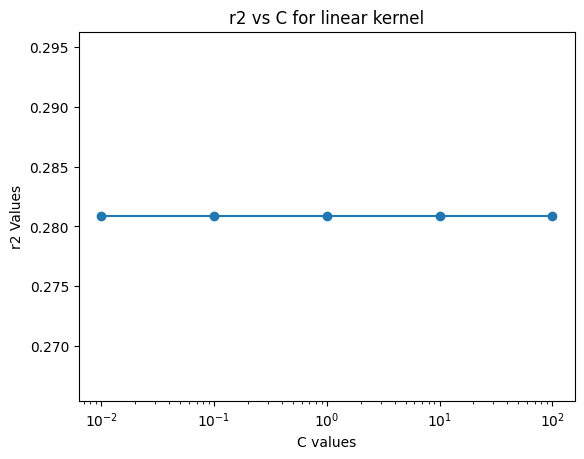

8
done fit
0.13383870034902512
10
done fit
0.24304939973808404
15
done fit
0.24809200476771132
22
done fit
0.524782046966696
25
done fit
0.35808156632002963


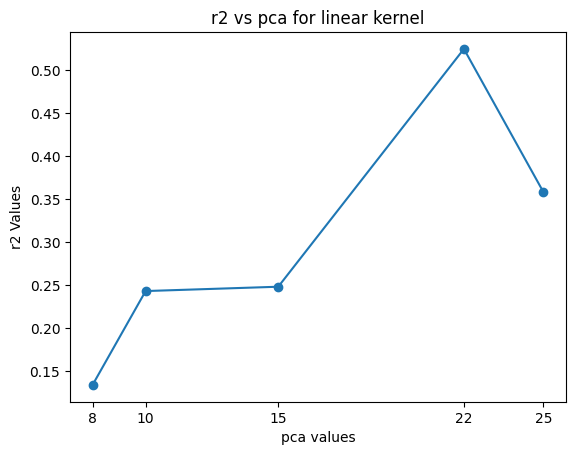

In [16]:
# TODO: Visualize performance vs C/gamma/degree
# Example: line plot of RMSE vs C for a fixed kernel
C = [0.01, 0.1, 1, 10, 100]
gamma = [0.001, 0.01, 0.1, 1]
n_components = [8, 10, 15, 22, 25]
kernel = 'linear'

perform_var_reg(C, "C", kernel=kernel)

perform_var_reg(n_components, "pca", kernel=kernel)
# perform_var_reg(gamma, 'gamma', kernel=kernel)

# perform_var_reg(degree, 'degree', kernel=kernel)

In [18]:
svr = svm_regressor(kernel, C=0.01)
pipeline = Pipeline([
            ("imputer", SimpleImputer()),
            ("scaler", StandardScaler()),   
            ("pca", PCA(n_components=22, random_state=42)),
            ("model", svr),])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
plot_regression_results(y_test, y_pred, '../outputs/aging/pca_reg_results.png')
plot_residuals(y_test, y_pred, '../outputs/aging/pca_residual.png')

